<a href="https://colab.research.google.com/github/Nishikant090/Proactive-Handover-Trigger-Prediction-in-5G-Networks-Using-Time-Series-Forecasting-Models/blob/main/signalforecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

df1 = pd.read_csv('dataset/drive_test_measurements01.csv').drop(columns=['Unnamed: 0'])
df2 = pd.read_csv('dataset/drive_test_measurements02.csv').drop(columns=['Unnamed: 0'])
df3 = pd.read_csv('dataset/drive_test_measurements03.csv').drop(columns=['Unnamed: 0'])

lon1 = df1['Lon'].copy()
df1['Lon'] = df1['Lat']
df1['Lat'] = lon1

lon2 = df2['Lon'].copy()
df2['Lon'] = df2['Lat']
df2['Lat'] = lon2

lon3 = df3['Lon'].copy()
df3['Lon'] = df3['Lat']
df3['Lat'] = lon3

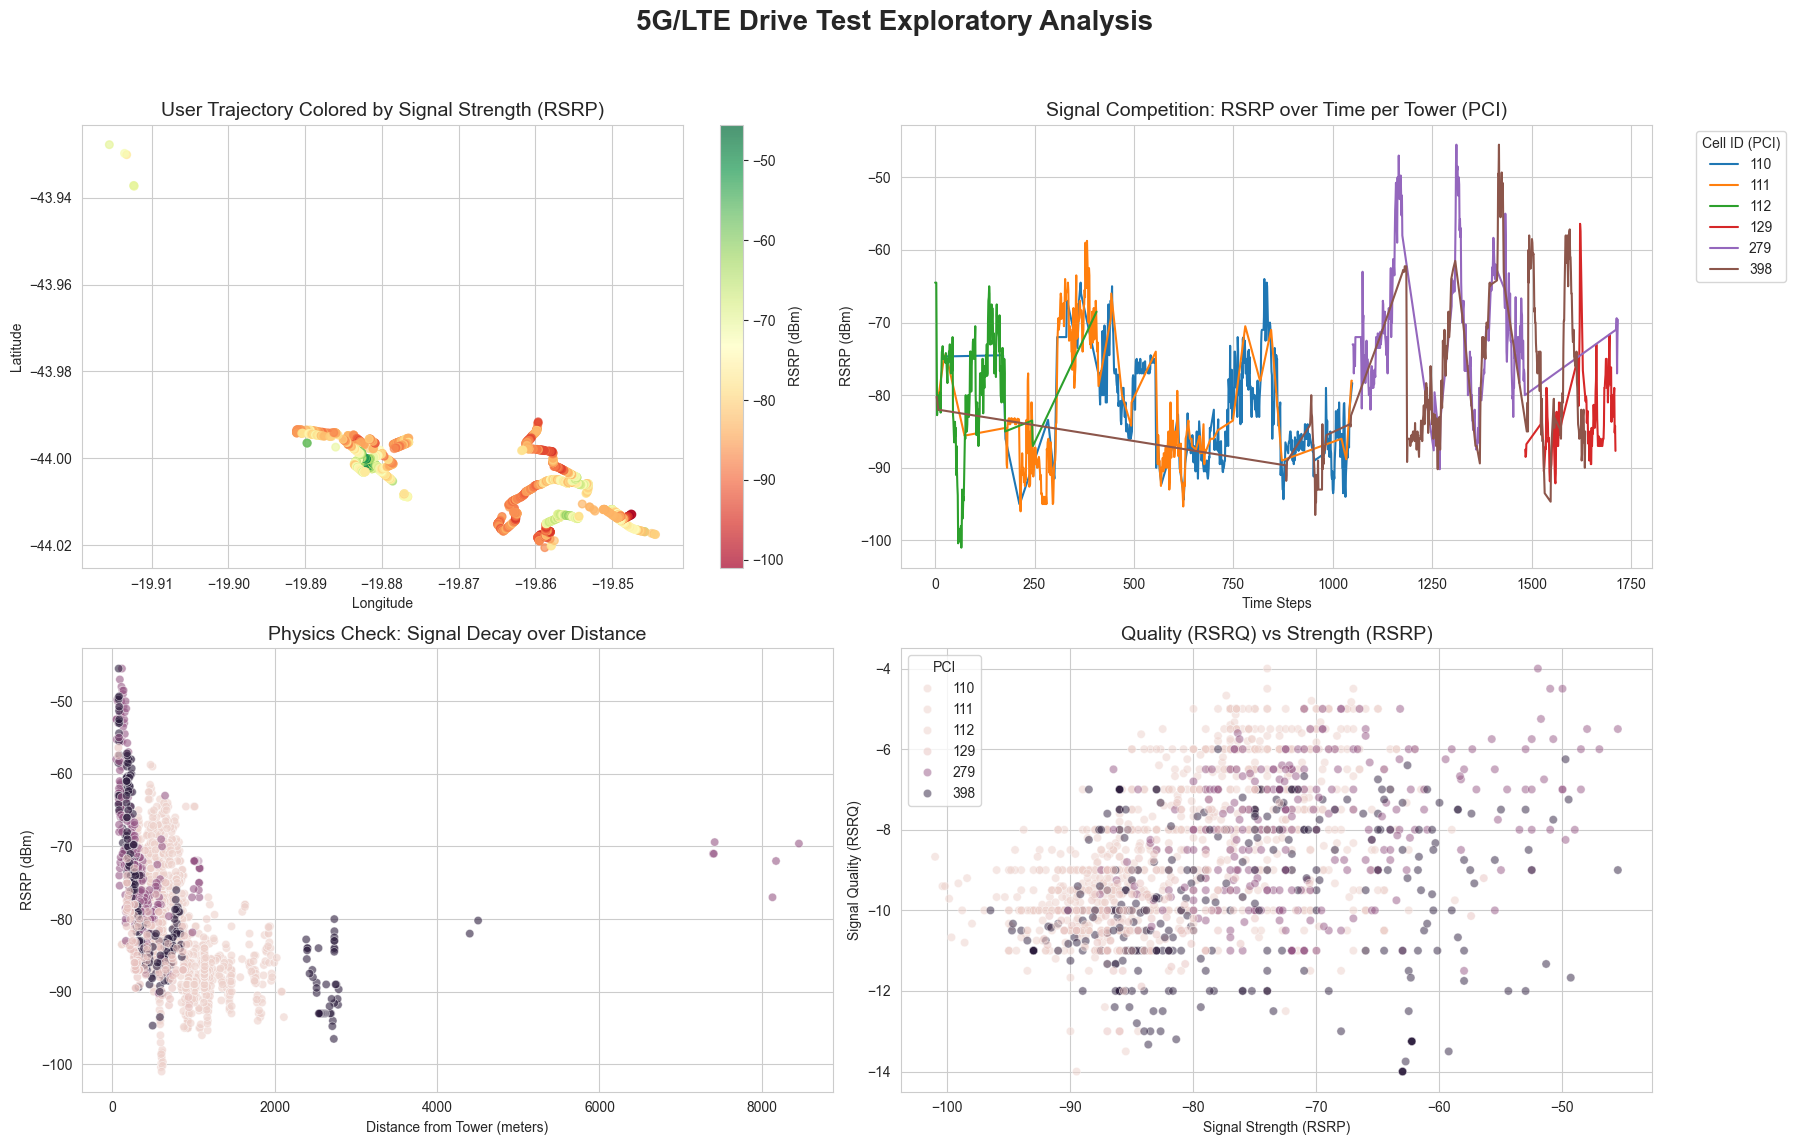


--- DATASET INSIGHTS ---
1. Total Data Points: 1718
2. Unique Towers Seen (PCIs): 6 towers -> [112 398 111 110 279 129]
3. Average Signal Strength: -78.99 dBm
4. Weakest Signal Detected: -101.0 dBm
5. Strongest Signal Detected: -45.5 dBm
6. Estimated Handovers (Cell Switches): 185 times


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df1
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('5G/LTE Drive Test Exploratory Analysis', fontsize=20, weight='bold')

sc = axes[0, 0].scatter(df['Lon'], df['Lat'],
                        c=df['RSRP'], cmap='RdYlGn', s=30, alpha=0.7)
axes[0, 0].set_title('User Trajectory Colored by Signal Strength (RSRP)', fontsize=14)
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
plt.colorbar(sc, ax=axes[0, 0], label='RSRP (dBm)')

sns.lineplot(data=df, x=df.index, y='RSRP', hue='PCI',
             palette='tab10', ax=axes[0, 1], linewidth=1.5)
axes[0, 1].set_title('Signal Competition: RSRP over Time per Tower (PCI)', fontsize=14)
axes[0, 1].set_xlabel('Time Steps')
axes[0, 1].set_ylabel('RSRP (dBm)')
axes[0, 1].legend(title='Cell ID (PCI)', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.scatterplot(data=df, x='Distance (m)', y='RSRP', hue='PCI',
                alpha=0.6, ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Physics Check: Signal Decay over Distance', fontsize=14)
axes[1, 0].set_xlabel('Distance from Tower (meters)')
axes[1, 0].set_ylabel('RSRP (dBm)')

sns.scatterplot(data=df, x='RSRP', y='RSRQ', hue='PCI',
                alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Quality (RSRQ) vs Strength (RSRP)', fontsize=14)
axes[1, 1].set_xlabel('Signal Strength (RSRP)')
axes[1, 1].set_ylabel('Signal Quality (RSRQ)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- DATASET INSIGHTS ---")
print(f"1. Total Data Points: {len(df)}")
print(f"2. Unique Towers Seen (PCIs): {df['PCI'].nunique()} towers -> {df['PCI'].unique()}")
print(f"3. Average Signal Strength: {df['RSRP'].mean():.2f} dBm")
print(f"4. Weakest Signal Detected: {df['RSRP'].min()} dBm")
print(f"5. Strongest Signal Detected: {df['RSRP'].max()} dBm")

best_cells = df.loc[df.groupby(df.index)['RSRP'].idxmax()]['PCI']
handovers = (best_cells != best_cells.shift()).sum()
print(f"6. Estimated Handovers (Cell Switches): {handovers} times")

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df.head(5000),
    x='Sequence_ID',
    y='PCI',
    hue='PCI',
    palette='tab10',
    s=50,  # Dot size
    alpha=0.8 # Transparency
)

plt.title('Timeline of Visible Cells (PCI) over Time', fontsize=16)
plt.xlabel('Time Step (Sequence ID)', fontsize=12)
plt.ylabel('Cell ID (PCI)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='PCI', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Sequence_ID` for `x`. An entry with this name does not appear in `data`.

<Figure size 1500x600 with 0 Axes>

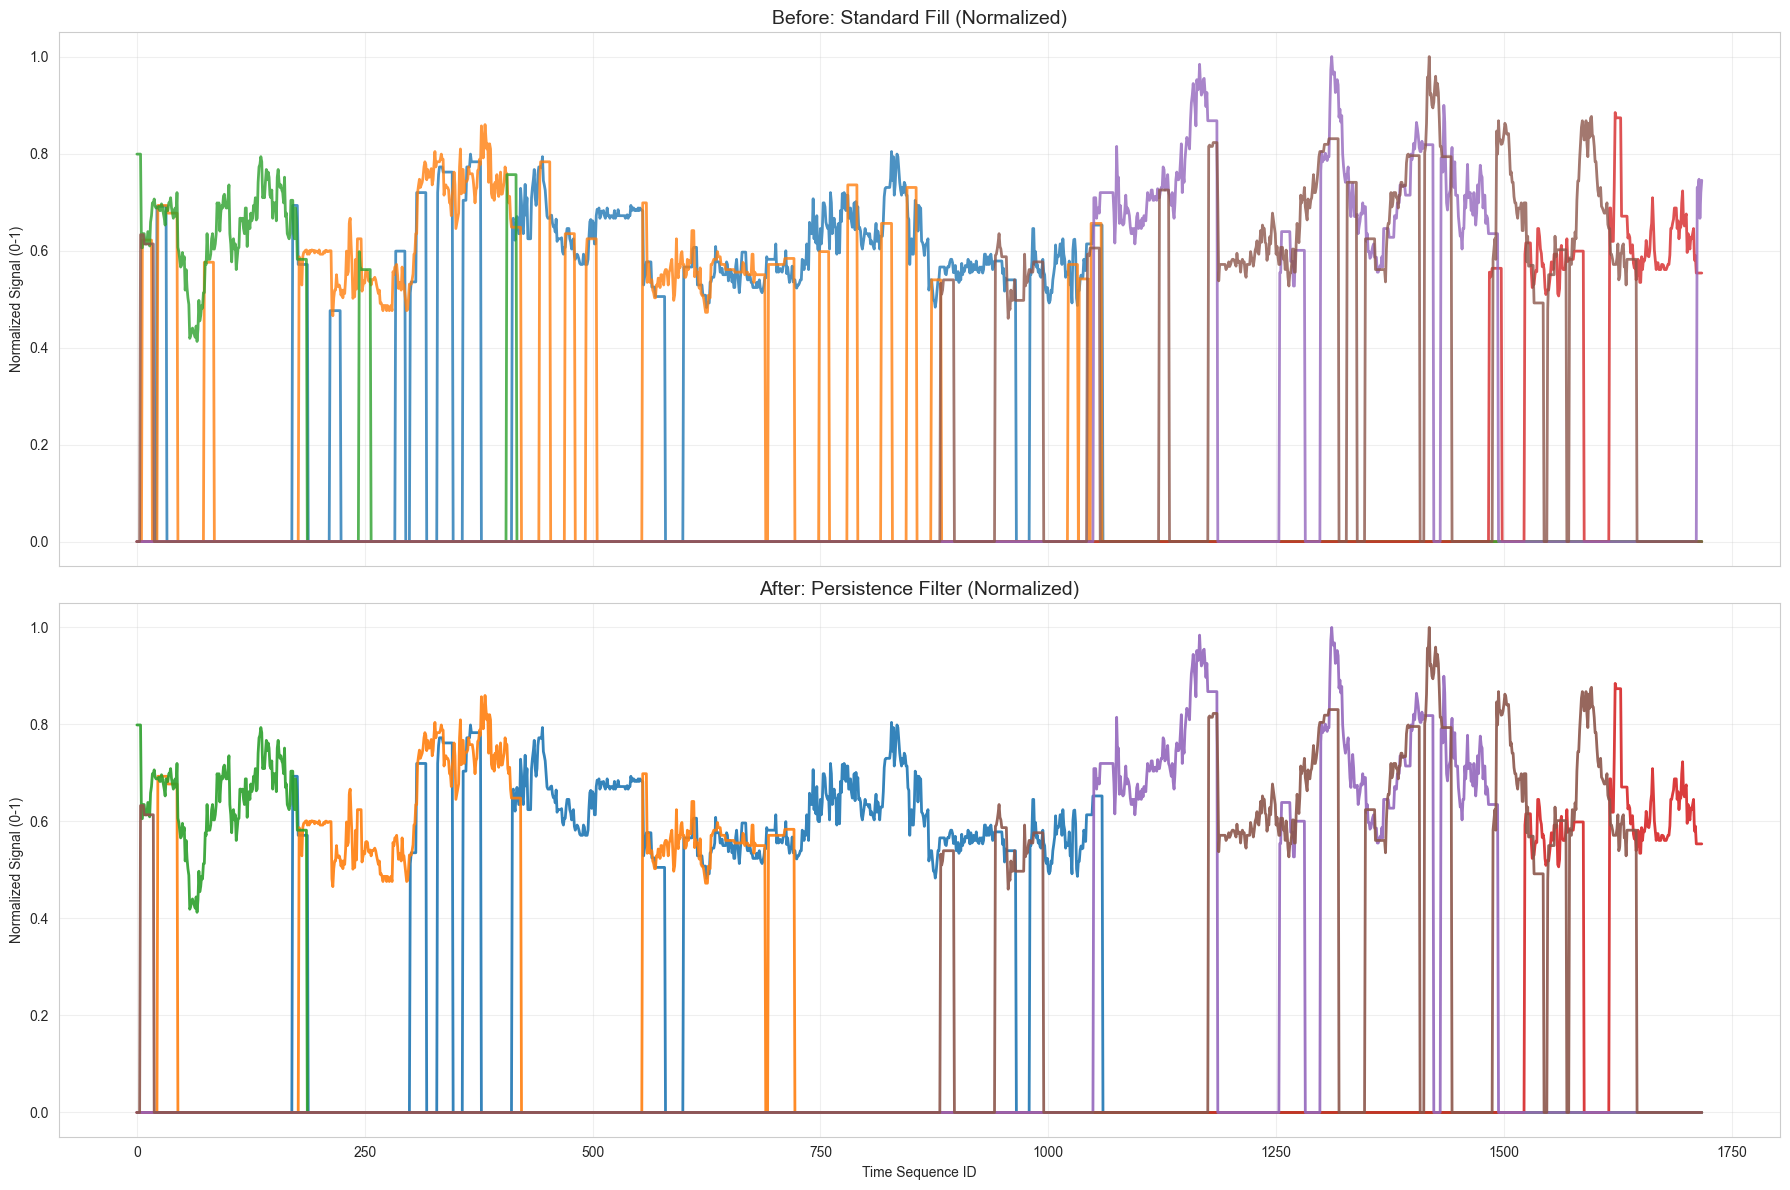

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

NOISE_FLOOR = -140
FFILL_LIMIT = 10
MIN_STAY_THRESHOLD = 15

df = df.sort_index()
df['Sequence_ID'] = df.index

matrix_filled = df.pivot_table(index='Sequence_ID', columns='PCI', values='RSRP')
matrix_filled = matrix_filled.ffill(limit=FFILL_LIMIT).fillna(NOISE_FLOOR)

def apply_persistence_filter(df_matrix, threshold, noise_floor):
    clean_df = df_matrix.copy()
    for col in clean_df.columns:
        is_active = clean_df[col] > noise_floor
        groups = (is_active != is_active.shift()).cumsum()
        block_lengths = is_active.groupby(groups).transform('count')
        mask_to_kill = is_active & (block_lengths < threshold)
        clean_df.loc[mask_to_kill, col] = noise_floor
    return clean_df

matrix_despiked = apply_persistence_filter(matrix_filled, MIN_STAY_THRESHOLD, NOISE_FLOOR)

global_min = NOISE_FLOOR
global_max = matrix_filled.max().max()

matrix_filled_norm = (matrix_filled - global_min) / (global_max - global_min)
matrix_despiked_norm = (matrix_despiked - global_min) / (global_max - global_min)

matrix_filled_norm = matrix_filled_norm.clip(0, 1)
matrix_despiked_norm = matrix_despiked_norm.clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)
palette = sns.color_palette("tab10", n_colors=len(matrix_filled.columns))

for i, pci in enumerate(matrix_filled_norm.columns):
    axes[0].plot(matrix_filled_norm.index, matrix_filled_norm[pci],
                 linewidth=2, label=f'PCI {pci}', color=palette[i], alpha=0.8)
axes[0].set_title(f'Before: Standard Fill (Normalized)', fontsize=14)
axes[0].set_ylabel('Normalized Signal (0-1)')
axes[0].grid(True, alpha=0.3)

for i, pci in enumerate(matrix_despiked_norm.columns):
    axes[1].plot(matrix_despiked_norm.index, matrix_despiked_norm[pci],
                 linewidth=2, label=f'PCI {pci}', color=palette[i], alpha=0.9)
axes[1].set_title(f'After: Persistence Filter (Normalized)', fontsize=14)
axes[1].set_xlabel('Time Sequence ID')
axes[1].set_ylabel('Normalized Signal (0-1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

DEVICE = torch.device("cpu")

NOISE_FLOOR = -140.0
MAX_DBM = -40.0
DYNAMIC_RANGE = MAX_DBM - NOISE_FLOOR

INPUT_STEPS = 32
FORECAST_STEPS = 25
TOTAL_WINDOW = INPUT_STEPS + FORECAST_STEPS

SEGMENT_LEN = 8
NUM_SEGMENTS = INPUT_STEPS // SEGMENT_LEN

MASK_THRESHOLD_DB = 5.0
TARGET_TTT_IDX = 4
TARGET_MTS_IDX = 24

BATCH_SIZE = 64
MAX_LR = 0.005
EPOCHS = 2000

def prepare_data(list_of_dfs):
    combined_raw = pd.concat(list_of_dfs, ignore_index=True)

    if 'Time' not in combined_raw.columns:
        combined_raw['Time'] = combined_raw.index

    matrix_df = combined_raw.pivot_table(index='Time', columns='PCI', values='RSRP')
    matrix_df = matrix_df.interpolate(method='linear', limit=10).fillna(NOISE_FLOOR)

    norm_vals = (matrix_df.values - NOISE_FLOOR) / DYNAMIC_RANGE
    norm_vals = np.clip(norm_vals, 0, 1)

    n_time, n_cells = norm_vals.shape

    X_list, Y_list, M_list = [], [], []

    for i in range(0, n_time - TOTAL_WINDOW):
        x_win = norm_vals[i : i + INPUT_STEPS, :]
        y_win = norm_vals[i + INPUT_STEPS : i + TOTAL_WINDOW, :]

        y_dbm = y_win * DYNAMIC_RANGE + NOISE_FLOOR
        best_dbm = np.max(y_dbm, axis=1, keepdims=True)
        mask_win = (y_dbm >= (best_dbm - MASK_THRESHOLD_DB)).astype(np.float32)

        if mask_win.sum() > 0:
            X_list.append(x_win)
            Y_list.append(y_win)
            M_list.append(mask_win)

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    M = np.array(M_list, dtype=np.float32)

    X_train, X_test, Y_train, Y_test, M_train, M_test = train_test_split(
        X, Y, M, test_size=0.2, shuffle=True, random_state=42
    )

    return (X_train, Y_train, M_train), (X_test, Y_test, M_test), n_cells

class SegRNN(nn.Module):
    def __init__(self, num_cells, hidden_size=128, segment_len=SEGMENT_LEN):
        super(SegRNN, self).__init__()

        self.segment_len = segment_len
        self.num_cells = num_cells

        self.gru = nn.GRU(
            input_size=num_cells * segment_len,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, num_cells * FORECAST_STEPS)
        )

    def forward(self, x):
        B, T, C = x.shape
        x_seg = x.view(B, -1, self.segment_len * C)
        out, _ = self.gru(x_seg)

        last_hidden = out[:, -1, :]
        flat_pred = self.head(last_hidden)

        return flat_pred.view(-1, FORECAST_STEPS, self.num_cells)

def hybrid_loss(pred, target, mask):
    diff = torch.abs(pred - target)
    active_loss = (diff * mask).sum() / (mask.sum() + 1e-6)
    background_loss = (diff * (1 - mask)).mean()
    return active_loss + 0.2 * background_loss

def calculate_top1_margin_acc(pred_dbm, true_dbm):
    true_best_val = np.max(true_dbm, axis=1)
    pred_best_idx = np.argmax(pred_dbm, axis=1)
    true_val_of_pred_best = true_dbm[np.arange(len(true_dbm)), pred_best_idx]

    diff = np.abs(true_best_val - true_val_of_pred_best)
    correct = (diff <= 5.0).astype(np.float32)
    return np.mean(correct) * 100

if __name__ == "__main__":
    dfs = [df1]
    (tr_x, tr_y, tr_m), (te_x, te_y, te_m), n_cells = prepare_data(dfs)

    train_loader = DataLoader(TensorDataset(torch.tensor(tr_x), torch.tensor(tr_y), torch.tensor(tr_m)),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(te_x), torch.tensor(te_y), torch.tensor(te_m)),
                             batch_size=BATCH_SIZE)

    model = SegRNN(num_cells=n_cells).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=MAX_LR,
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS
    )

    for epoch in range(EPOCHS):
        model.train()
        ep_loss = 0
        for bx, by, bm in train_loader:
            bx, by, bm = bx.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)

            optimizer.zero_grad()
            pred = model(bx)
            loss = hybrid_loss(pred, by, bm)
            loss.backward()
            optimizer.step()
            scheduler.step()
            ep_loss += loss.item()

        if (epoch+1) % 10 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1} | Loss: {ep_loss/len(train_loader):.4f} | LR: {current_lr:.5f}")

    print("\n" + "="*50)
    print(f"{'METRIC':<10} | {'TTT (160ms)':<15} | {'MTS (1000ms)':<15}")
    print("="*50)

    model.eval()
    metrics = {'TTT': {'mae': [], 'acc': []}, 'MTS': {'mae': [], 'acc': []}}

    with torch.no_grad():
        for bx, by, bm in test_loader:
            bx = bx.to(DEVICE)
            by = by.cpu().numpy()
            bm = bm.cpu().numpy()
            pred = model(bx).cpu().numpy()

            p_dbm = pred * DYNAMIC_RANGE + NOISE_FLOOR
            t_dbm = by * DYNAMIC_RANGE + NOISE_FLOOR

            def calc_step_metrics(idx, key):
                if idx >= FORECAST_STEPS: return

                diff = np.abs(p_dbm[:, idx, :] - t_dbm[:, idx, :])
                mask = bm[:, idx, :]
                if mask.sum() > 0:
                    metrics[key]['mae'].extend(diff[mask==1])

                acc = calculate_top1_margin_acc(p_dbm[:, idx, :], t_dbm[:, idx, :])
                metrics[key]['acc'].append(acc)

            calc_step_metrics(TARGET_TTT_IDX, 'TTT')
            calc_step_metrics(TARGET_MTS_IDX, 'MTS')

    print(f"{'MAE':<10} | {np.mean(metrics['TTT']['mae']):<15.4f} | {np.mean(metrics['MTS']['mae']):<15.4f}  (dB)")
    print(f"{'ACCURACY':<10} | {np.mean(metrics['TTT']['acc']):<15.2f} | {np.mean(metrics['MTS']['acc']):<15.2f}  (%)")
    print("="*50)

Epoch 10 | Loss: 0.1274 | LR: 0.00020
Epoch 20 | Loss: 0.1138 | LR: 0.00021
Epoch 30 | Loss: 0.1055 | LR: 0.00023
Epoch 40 | Loss: 0.0977 | LR: 0.00025
Epoch 50 | Loss: 0.0929 | LR: 0.00028
Epoch 60 | Loss: 0.0892 | LR: 0.00032
Epoch 70 | Loss: 0.0836 | LR: 0.00036
Epoch 80 | Loss: 0.0790 | LR: 0.00041
Epoch 90 | Loss: 0.0728 | LR: 0.00046
Epoch 100 | Loss: 0.0693 | LR: 0.00052
Epoch 110 | Loss: 0.0677 | LR: 0.00059
Epoch 120 | Loss: 0.0652 | LR: 0.00066
Epoch 130 | Loss: 0.0609 | LR: 0.00073
Epoch 140 | Loss: 0.0610 | LR: 0.00082
Epoch 150 | Loss: 0.0563 | LR: 0.00090
Epoch 160 | Loss: 0.0546 | LR: 0.00099
Epoch 170 | Loss: 0.0536 | LR: 0.00109
Epoch 180 | Loss: 0.0507 | LR: 0.00119
Epoch 190 | Loss: 0.0483 | LR: 0.00129
Epoch 200 | Loss: 0.0462 | LR: 0.00140
Epoch 210 | Loss: 0.0443 | LR: 0.00151
Epoch 220 | Loss: 0.0419 | LR: 0.00162
Epoch 230 | Loss: 0.0411 | LR: 0.00174
Epoch 240 | Loss: 0.0384 | LR: 0.00186
Epoch 250 | Loss: 0.0380 | LR: 0.00198
Epoch 260 | Loss: 0.0377 | LR: 0.0

changesssss

In [11]:
# ===================== FULL IMPROVED VERSION =====================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# ===============================================================
# SETTINGS
# ===============================================================

DEVICE = torch.device("cpu")

NOISE_FLOOR = -140.0
MAX_DBM = -40.0
DYNAMIC_RANGE = MAX_DBM - NOISE_FLOOR

INPUT_STEPS = 32
FORECAST_STEPS = 25
TOTAL_WINDOW = INPUT_STEPS + FORECAST_STEPS

SEGMENT_LEN = 8
MASK_THRESHOLD_DB = 5.0
TARGET_TTT_IDX = 4
TARGET_MTS_IDX = 24

BATCH_SIZE = 64
MAX_LR = 0.005
EPOCHS = 2000


# ===============================================================
# DATA PREP
# ===============================================================

def prepare_data(list_of_dfs):

    combined_raw = pd.concat(list_of_dfs, ignore_index=True)

    if 'Time' not in combined_raw.columns:
        combined_raw['Time'] = combined_raw.index

    matrix_df = combined_raw.pivot_table(index='Time', columns='PCI', values='RSRP')
    matrix_df = matrix_df.interpolate(method='linear', limit=10).fillna(NOISE_FLOOR)

    norm_vals = (matrix_df.values - NOISE_FLOOR) / DYNAMIC_RANGE
    norm_vals = np.clip(norm_vals, 0, 1)

    n_time, n_cells = norm_vals.shape

    X_list, Y_list, M_list = [], [], []

    for i in range(0, n_time - TOTAL_WINDOW):

        x_win = norm_vals[i:i+INPUT_STEPS]
        y_win = norm_vals[i+INPUT_STEPS:i+TOTAL_WINDOW]

        y_dbm = y_win * DYNAMIC_RANGE + NOISE_FLOOR
        best_dbm = np.max(y_dbm, axis=1, keepdims=True)

        mask_win = (y_dbm >= (best_dbm - MASK_THRESHOLD_DB)).astype(np.float32)

        if mask_win.sum() > 0:
            X_list.append(x_win)
            Y_list.append(y_win)
            M_list.append(mask_win)

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    M = np.array(M_list, dtype=np.float32)

    X_train, X_test, Y_train, Y_test, M_train, M_test = train_test_split(
        X, Y, M,
        test_size=0.2,
        shuffle=True,
        random_state=42
    )

    return (X_train, Y_train, M_train), (X_test, Y_test, M_test), n_cells


# ===============================================================
# MODEL
# ===============================================================

class SegRNN(nn.Module):

    def __init__(self, num_cells, hidden_size=160):  # ⭐ Increased capacity
        super().__init__()

        self.segment_len = SEGMENT_LEN
        self.num_cells = num_cells

        self.gru = nn.GRU(
            input_size=num_cells * SEGMENT_LEN,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, num_cells * FORECAST_STEPS)
        )

    def forward(self, x):

        B, T, C = x.shape
        x_seg = x.view(B, -1, self.segment_len * C)

        out, _ = self.gru(x_seg)
        flat_pred = self.head(out[:, -1])

        return flat_pred.view(-1, FORECAST_STEPS, self.num_cells)


# ===============================================================
# LOSS + METRIC
# ===============================================================

def hybrid_loss(pred, target, mask):
    diff = torch.abs(pred - target)

    active_loss = (diff * mask).sum() / (mask.sum() + 1e-6)
    background_loss = (diff * (1 - mask)).mean()

    return active_loss + 0.15 * background_loss   # ⭐ Rebalanced


def calculate_top1_margin_acc(pred_dbm, true_dbm):

    true_best_val = np.max(true_dbm, axis=1)
    pred_best_idx = np.argmax(pred_dbm, axis=1)

    true_val_of_pred_best = true_dbm[np.arange(len(true_dbm)), pred_best_idx]

    diff = np.abs(true_best_val - true_val_of_pred_best)

    return np.mean((diff <= 5.0).astype(np.float32)) * 100


# ===============================================================
# MAIN TRAINING
# ===============================================================

if __name__ == "__main__":

    # ⭐ Use all datasets if available
    dfs = [df1]      # change to [df1, df2, df3]

    (tr_x, tr_y, tr_m), (te_x, te_y, te_m), n_cells = prepare_data(dfs)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(tr_x), torch.tensor(tr_y), torch.tensor(tr_m)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        pin_memory=True  # ⭐ Faster transfer
    )

    test_loader = DataLoader(
        TensorDataset(torch.tensor(te_x), torch.tensor(te_y), torch.tensor(te_m)),
        batch_size=BATCH_SIZE,
        pin_memory=True
    )

    model = SegRNN(n_cells).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=MAX_LR,
        steps_per_epoch=len(train_loader),
        epochs=EPOCHS
    )

    # ================= TRAIN =================
    for epoch in range(EPOCHS):

        model.train()
        ep_loss = 0

        for bx, by, bm in train_loader:

            bx, by, bm = bx.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)

            optimizer.zero_grad()

            pred = model(bx)
            loss = hybrid_loss(pred, by, bm)

            loss.backward()

            # ⭐ Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            ep_loss += loss.item()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss {ep_loss/len(train_loader):.4f}")

    # ===============================================================
    # EVALUATION
    # ===============================================================

    print("\n" + "="*50)
    print(f"{'METRIC':<10} | {'TTT (160ms)':<15} | {'MTS (1000ms)':<15}")
    print("="*50)

    model.eval()
    metrics = {'TTT': {'mae': [], 'acc': []}, 'MTS': {'mae': [], 'acc': []}}

    with torch.no_grad():

        for bx, by, bm in test_loader:

            bx = bx.to(DEVICE)
            by = by.numpy()
            bm = bm.numpy()

            pred = model(bx).cpu().numpy()

            p_dbm = pred * DYNAMIC_RANGE + NOISE_FLOOR
            t_dbm = by * DYNAMIC_RANGE + NOISE_FLOOR

            def calc_step(idx, key):

                if idx >= FORECAST_STEPS:
                    return

                diff = np.abs(p_dbm[:, idx, :] - t_dbm[:, idx, :])
                mask = bm[:, idx, :]

                if mask.sum() > 0:
                    metrics[key]['mae'].extend(diff[mask == 1])

                acc = calculate_top1_margin_acc(
                    p_dbm[:, idx, :],
                    t_dbm[:, idx, :]
                )

                metrics[key]['acc'].append(acc)

            calc_step(TARGET_TTT_IDX, 'TTT')
            calc_step(TARGET_MTS_IDX, 'MTS')

    print(f"{'MAE':<10} | {np.mean(metrics['TTT']['mae']):<15.4f} | {np.mean(metrics['MTS']['mae']):<15.4f} (dB)")
    print(f"{'ACCURACY':<10} | {np.mean(metrics['TTT']['acc']):<15.2f} | {np.mean(metrics['MTS']['acc']):<15.2f} (%)")
    print("="*50)


ModuleNotFoundError: No module named 'sklearn'

In [14]:
# ===================== ULTRA OPTIMIZED VERSION =====================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# ===============================================================
# SETTINGS
# ===============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NOISE_FLOOR = -140.0
MAX_DBM = -40.0
DYNAMIC_RANGE = MAX_DBM - NOISE_FLOOR

INPUT_STEPS = 32
FORECAST_STEPS = 25
TOTAL_WINDOW = INPUT_STEPS + FORECAST_STEPS

SEGMENT_LEN = 8
MASK_THRESHOLD_DB = 5.0
TARGET_TTT_IDX = 4
TARGET_MTS_IDX = 24

BATCH_SIZE = 64
MAX_LR = 0.003
EPOCHS = 800
PATIENCE = 50


# ===============================================================
# DATA PREP
# ===============================================================

def prepare_data(list_of_dfs):

    combined_raw = pd.concat(list_of_dfs, ignore_index=True)

    if 'Time' not in combined_raw.columns:
        combined_raw['Time'] = combined_raw.index

    matrix_df = combined_raw.pivot_table(index='Time', columns='PCI', values='RSRP')
    matrix_df = matrix_df.interpolate(method='linear', limit=10).fillna(NOISE_FLOOR)

    norm_vals = (matrix_df.values - NOISE_FLOOR) / DYNAMIC_RANGE
    norm_vals = np.clip(norm_vals, 0, 1)

    n_time, n_cells = norm_vals.shape

    X_list, Y_list, M_list = [], [], []

    for i in range(0, n_time - TOTAL_WINDOW):

        x_win = norm_vals[i:i+INPUT_STEPS]
        y_win = norm_vals[i+INPUT_STEPS:i+TOTAL_WINDOW]

        y_dbm = y_win * DYNAMIC_RANGE + NOISE_FLOOR
        best_dbm = np.max(y_dbm, axis=1, keepdims=True)

        mask_win = (y_dbm >= (best_dbm - MASK_THRESHOLD_DB)).astype(np.float32)

        if mask_win.sum() > 0:
            X_list.append(x_win)
            Y_list.append(y_win)
            M_list.append(mask_win)

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    M = np.array(M_list, dtype=np.float32)

    X_train, X_test, Y_train, Y_test, M_train, M_test = train_test_split(
        X, Y, M,
        test_size=0.2,
        shuffle=True,
        random_state=42
    )

    return (X_train, Y_train, M_train), (X_test, Y_test, M_test), n_cells


# ===============================================================
# MODEL
# ===============================================================

class SegRNN(nn.Module):

    def __init__(self, num_cells, hidden_size=192):
        super().__init__()

        self.segment_len = SEGMENT_LEN
        self.num_cells = num_cells

        self.gru = nn.GRU(
            input_size=num_cells * SEGMENT_LEN,
            hidden_size=hidden_size,
            num_layers=3,
            batch_first=True,
            dropout=0.3
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            batch_first=True
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Linear(hidden_size // 2, num_cells * FORECAST_STEPS)
        )

    def forward(self, x):

        B, T, C = x.shape

        last_input = x[:, -1:, :]  # residual anchor

        x_seg = x.view(B, -1, self.segment_len * C)

        out, _ = self.gru(x_seg)

        attn_out, _ = self.attn(out, out, out)

        flat_pred = self.head(attn_out[:, -1])

        pred = flat_pred.view(-1, FORECAST_STEPS, self.num_cells)

        return pred + last_input  # residual learning


# ===============================================================
# LOSS
# ===============================================================

def hybrid_loss(pred, target, mask):

    huber = nn.SmoothL1Loss(reduction='none')
    diff = huber(pred, target)

    active_loss = (diff * mask).sum() / (mask.sum() + 1e-6)
    background_loss = (diff * (1 - mask)).mean()

    return active_loss + 0.1 * background_loss


# ===============================================================
# METRIC
# ===============================================================

def calculate_top1_margin_acc(pred_dbm, true_dbm):

    true_best_val = np.max(true_dbm, axis=1)
    pred_best_idx = np.argmax(pred_dbm, axis=1)
    true_val_of_pred_best = true_dbm[np.arange(len(true_dbm)), pred_best_idx]

    diff = np.abs(true_best_val - true_val_of_pred_best)

    return np.mean((diff <= 5.0).astype(np.float32)) * 100


# ===============================================================
# TRAINING
# ===============================================================

if __name__ == "__main__":

    dfs = [df1]  # Add more datasets if available

    (tr_x, tr_y, tr_m), (te_x, te_y, te_m), n_cells = prepare_data(dfs)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(tr_x), torch.tensor(tr_y), torch.tensor(tr_m)),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(torch.tensor(te_x), torch.tensor(te_y), torch.tensor(te_m)),
        batch_size=BATCH_SIZE
    )

    model = SegRNN(n_cells).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-5
    )

    best_loss = float('inf')
    counter = 0

    for epoch in range(EPOCHS):

        model.train()
        ep_loss = 0

        for bx, by, bm in train_loader:

            bx, by, bm = bx.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)

            optimizer.zero_grad()

            pred = model(bx)
            loss = hybrid_loss(pred, by, bm)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            ep_loss += loss.item()

        scheduler.step()

        avg_loss = ep_loss / len(train_loader)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss {avg_loss:.5f}")

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= PATIENCE:
            print("Early stopping triggered")
            break

    # Load best model
    model.load_state_dict(torch.load("best_model.pth"))

    # ===============================================================
    # EVALUATION
    # ===============================================================

    print("\n" + "="*50)
    print(f"{'METRIC':<10} | {'TTT (160ms)':<15} | {'MTS (1000ms)':<15}")
    print("="*50)

    model.eval()

    metrics = {'TTT': {'mae': [], 'acc': []}, 'MTS': {'mae': [], 'acc': []}}

    with torch.no_grad():

        for bx, by, bm in test_loader:

            bx = bx.to(DEVICE)
            by = by.numpy()
            bm = bm.numpy()

            pred = model(bx).cpu().numpy()

            p_dbm = pred * DYNAMIC_RANGE + NOISE_FLOOR
            t_dbm = by * DYNAMIC_RANGE + NOISE_FLOOR

            def calc_step(idx, key):

                if idx >= FORECAST_STEPS:
                    return

                diff = np.abs(p_dbm[:, idx, :] - t_dbm[:, idx, :])
                mask = bm[:, idx, :]

                if mask.sum() > 0:
                    metrics[key]['mae'].extend(diff[mask == 1])

                acc = calculate_top1_margin_acc(
                    p_dbm[:, idx, :],
                    t_dbm[:, idx, :]
                )

                metrics[key]['acc'].append(acc)

            calc_step(TARGET_TTT_IDX, 'TTT')
            calc_step(TARGET_MTS_IDX, 'MTS')

    print(f"{'MAE':<10} | {np.mean(metrics['TTT']['mae']):<15.4f} | {np.mean(metrics['MTS']['mae']):<15.4f} (dB)")
    print(f"{'ACCURACY':<10} | {np.mean(metrics['TTT']['acc']):<15.2f} | {np.mean(metrics['MTS']['acc']):<15.2f} (%)")
    print("="*50)


Epoch 10 | Loss 0.00919
Epoch 20 | Loss 0.00667
Epoch 30 | Loss 0.00520
Epoch 40 | Loss 0.00428
Epoch 50 | Loss 0.00350
Epoch 60 | Loss 0.00397
Epoch 70 | Loss 0.00321
Epoch 80 | Loss 0.00477
Epoch 90 | Loss 0.00340
Epoch 100 | Loss 0.00273
Epoch 110 | Loss 0.00241
Epoch 120 | Loss 0.00295
Epoch 130 | Loss 0.00227
Epoch 140 | Loss 0.00235
Epoch 150 | Loss 0.00216
Epoch 160 | Loss 0.00212
Epoch 170 | Loss 0.00244
Epoch 180 | Loss 0.00192
Epoch 190 | Loss 0.00390
Epoch 200 | Loss 0.00320
Epoch 210 | Loss 0.00205
Epoch 220 | Loss 0.00175
Epoch 230 | Loss 0.00165
Epoch 240 | Loss 0.00178
Epoch 250 | Loss 0.00162
Epoch 260 | Loss 0.00190
Epoch 270 | Loss 0.00150
Epoch 280 | Loss 0.00167
Epoch 290 | Loss 0.00157
Epoch 300 | Loss 0.00166
Epoch 310 | Loss 0.00147
Epoch 320 | Loss 0.00130
Epoch 330 | Loss 0.00129
Epoch 340 | Loss 0.00148
Epoch 350 | Loss 0.00130
Epoch 360 | Loss 0.00118
Epoch 370 | Loss 0.00118
Epoch 380 | Loss 0.00155
Epoch 390 | Loss 0.00177
Epoch 400 | Loss 0.00118
Epoch 410